# Modelado predictivo por CCAA desde Azure PostgreSQL (TFM)

Versión del notebook `03_modelado_predictivo.ipynb` que **carga los datos desde la base de
datos de Azure** en lugar del feature store en parquet local.

- **Fuente de datos:** tabla `feature_store_modelado` en Azure Database for PostgreSQL
  (Flexible Server), materializada una sola vez con `scripts/build_feature_store_azure.py`
  (que replica exactamente la ingeniería de `src/features/builder.py`: pivot fase→columnas,
  ratios y lags por serie).
- **El modelado es idéntico al del notebook 03** (Paso 3c): modelo independiente por CCAA,
  grano nativo, objetivo `OBR` transformado con `log1p`/`expm1` vía `TransformedTargetRegressor`,
  split temporal (2 últimos años = test) y comparación honesta contra baselines
  (`OBR ≈ obr_lag_1` y `OBR ≈ CRE`).

> **Requisitos previos**
> 1. Feature store materializado en Azure:
>    `python scripts/build_feature_store_azure.py`
> 2. Contraseña de Azure en la variable de entorno **antes de lanzar Jupyter**:
>    - PowerShell: `$env:PGPASSWORD = 'tu_password'`
>    - Bash: `export PGPASSWORD='tu_password'`
> 3. La IP de este equipo autorizada en el firewall del servidor Azure.


## 1 · Configuración e imports

In [1]:
from __future__ import annotations
import os, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=0.95)
plt.rcParams["figure.dpi"] = 110

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORTS_DIR = ROOT / "reports" / "modelado_azure"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MAX_IMPORTE = 1e11

# --- Tabla del feature store en Azure ---
FS_TABLE = os.getenv("FS_TABLE", "feature_store_modelado")

CCAA_OBR = ["aragon","asturias","canarias","cataluna","madrid",
            "pais-vasco","castilla-y-leon","nacional","illes-balears","castilla-la-mancha"]
CCAA_NAMES = {"aragon":"Aragón","asturias":"Asturias","canarias":"Canarias","cataluna":"Cataluña",
              "madrid":"Madrid","pais-vasco":"País Vasco","castilla-y-leon":"Castilla y León",
              "nacional":"AGE (nacional)","illes-balears":"Illes Balears","castilla-la-mancha":"C.-La Mancha"}

TARGET = "OBR"
NUM_COLS = ["PRE","CRE","ratio_cre_pre","obr_lag_1","obr_lag_2","obr_lag_3","obr_lag_4","anio"]
MODEL_SPECS = {"ridge":Ridge(alpha=1.0),
               "random_forest":RandomForestRegressor(n_estimators=300,max_depth=6,random_state=42,n_jobs=-1),
               "xgboost":XGBRegressor(n_estimators=300,max_depth=4,learning_rate=0.05,random_state=42,tree_method="hist")}
TEST_N_YEARS = 2
print("ROOT:", ROOT, "| tabla:", FS_TABLE)

ROOT: C:\Users\usuario\Documents\Master\Projects\Ejecucion_presupuestaria | tabla: feature_store_modelado


## 2 · Conexión a Azure y carga del feature store

`load_ccaa(slug)` sustituye a la lectura de parquet del notebook 03: hace un `SELECT` filtrado
por CCAA sobre la tabla `feature_store_modelado`. El resto de funciones (`metrics`, `make_pipeline`)
son idénticas al notebook 03.

In [2]:
def make_engine():
    pwd = os.getenv("PGPASSWORD")
    if not pwd:
        raise RuntimeError(
            "Falta la variable de entorno PGPASSWORD.\n"
            "  PowerShell:  $env:PGPASSWORD = 'tu_password'   (y reinicia Jupyter)\n"
            "  Bash:        export PGPASSWORD='tu_password'")
    url = URL.create("postgresql+psycopg",
                     username=os.getenv("PGUSER", "adminuser"),
                     password=pwd,
                     host=os.getenv("PGHOST", "postgres-tfm.postgres.database.azure.com"),
                     port=int(os.getenv("PGPORT", "5432")),
                     database=os.getenv("PGDATABASE", "postgres"),
                     query={"sslmode": os.getenv("PGSSLMODE", "require")})
    return create_engine(url, pool_pre_ping=True)

def _read_sql(conn, sql, params=None):
    """Lee a DataFrame ejecutando vía SQLAlchemy. NOTA: no se usa `pd.read_sql`
    porque pandas 3.0 dejó de reconocer el Engine/Connection de SQLAlchemy 2.0
    como conectable ('Query must be a string unless using sqlalchemy'). Además se
    coercionan a numérico las columnas object (una columna numérica toda-NULL llega
    como object con None, no float NaN, y rompería `.abs()`); el texto se mantiene."""
    r = conn.execute(text(sql), params or {})
    df = pd.DataFrame(r.fetchall(), columns=list(r.keys()))
    for col in df.columns:
        if df[col].dtype == object:
            conv = pd.to_numeric(df[col], errors="coerce")
            if conv.notna().sum() >= df[col].notna().sum():
                df[col] = conv
    return df

ENGINE = make_engine()
# Comprobación de conexión + recuento por CCAA
with ENGINE.connect() as _c:
    _tot = _c.execute(text(f"SELECT COUNT(*) FROM {FS_TABLE}")).scalar()
    _by = _read_sql(_c,
        f"SELECT ccaa_slug, COUNT(*) AS filas FROM {FS_TABLE} GROUP BY ccaa_slug ORDER BY filas DESC")
print(f"[Azure] Conexión OK. {FS_TABLE}: {_tot:,} filas")
_by

def load_ccaa(slug):
    """Carga las features de una CCAA desde la tabla materializada en Azure."""
    with ENGINE.connect() as conn:
        d = _read_sql(conn, f"SELECT * FROM {FS_TABLE} WHERE ccaa_slug = :s", {"s": slug})
    return d

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    denom = np.where(np.abs(y_true) < 1e-6, np.nan, np.abs(y_true))
    return dict(mae=float(mean_absolute_error(y_true,y_pred)),
                rmse=float(np.sqrt(mean_squared_error(y_true,y_pred))),
                mape=float(np.nanmean(np.abs(y_true-y_pred)/denom)),
                r2=float(r2_score(y_true,y_pred)) if len(y_true)>=2 else np.nan)

def make_pipeline(model, cat_cols):
    """Pipeline (prep + estimador) con el target en log1p (inverso expm1)."""
    num_pipe = Pipeline([("imp",SimpleImputer(strategy="median")),("sc",StandardScaler())])
    cat_pipe = Pipeline([("imp",SimpleImputer(strategy="most_frequent")),
                         ("ohe",OneHotEncoder(handle_unknown="ignore",sparse_output=False))])
    prep = ColumnTransformer([("num",num_pipe,NUM_COLS),("cat",cat_pipe,cat_cols)], remainder="drop")
    inner = Pipeline([("prep",prep),("est",model)])
    return TransformedTargetRegressor(regressor=inner, func=np.log1p, inverse_func=np.expm1)
print("Funciones listas.")

[Azure] Conexión OK. feature_store_modelado: 19,328 filas
Funciones listas.


## 3 · Entrenamiento independiente por CCAA

In [3]:
import sklearn.base as skb
rows = []
PRED = {}      # ccaa -> dict(y=..., preds={modelo:...}, best=nombre)
IMPORT = {}    # ccaa -> (feat_names, importances) del mejor árbol

for slug in CCAA_OBR:
    d = load_ccaa(slug); nombre = CCAA_NAMES.get(slug, slug)
    if d.empty or TARGET not in d.columns: continue
    for c in ["PRE","OBR","CRE","PAG"]:
        if c in d.columns: d = d[~(d[c].abs() > MAX_IMPORTE)]
    d = d[d[TARGET].notna() & (d[TARGET] > 0)].copy()
    if "ratio_cre_pre" not in d.columns and {"CRE","PRE"} <= set(d.columns):
        d["ratio_cre_pre"] = d["CRE"] / d["PRE"].replace(0, np.nan)
    cat_cols = ["capitulo_id"] if ("capitulo_id" in d.columns and d["capitulo_id"].notna().any()) else []
    grano = "capítulo" if cat_cols else "entidad/CCAA"

    years = sorted(d["anio"].unique()); test_years = set(years[-TEST_N_YEARS:])
    train = d[~d["anio"].isin(test_years)]; test = d[d["anio"].isin(test_years)]
    base = dict(ccaa=nombre, grano=grano, n_train=len(train), n_test=len(test))
    if len(train) < 20 or len(test) < 5:
        rows.append({**base, "modelo":"—", "nota":"datos insuficientes"}); continue

    y_te = test[TARGET].to_numpy(float); fb = float(train[TARGET].median())
    preds = {}
    # Baselines: se evalúan en la ESCALA ORIGINAL (no se transforman con log1p)
    preds["baseline_lag1"] = test["obr_lag_1"].fillna(test["CRE"]).fillna(test["PRE"]).fillna(fb).to_numpy(float)
    preds["baseline_cre"]  = test["CRE"].fillna(test["PRE"]).fillna(fb).to_numpy(float)
    for name in ("baseline_lag1","baseline_cre"):
        rows.append({**base, "modelo":name, **metrics(y_te, preds[name])})

    feat = NUM_COLS + cat_cols
    Xtr, ytr, Xte = train[feat], train[TARGET], test[feat]
    best = (None, np.inf)
    for name, model in MODEL_SPECS.items():
        ttr = make_pipeline(skb.clone(model), cat_cols)   # target en log1p (inverso expm1)
        ttr.fit(Xtr, ytr); p = ttr.predict(Xte)
        preds[name] = p
        m = metrics(y_te, p); rows.append({**base, "modelo":name, **m})
        if m["mae"] < best[1]: best = (name, m["mae"])
        if name in ("random_forest","xgboost"):
            try:
                inner = ttr.regressor_
                fn = inner.named_steps["prep"].get_feature_names_out()
                IMPORT.setdefault(nombre, {})[name] = (fn, inner.named_steps["est"].feature_importances_)
            except Exception: pass
    cand = {k:metrics(y_te,v)["mae"] for k,v in preds.items()}
    winner = min(cand, key=cand.get)
    PRED[nombre] = dict(y=y_te, preds=preds, best=winner, grano=grano)

res = pd.DataFrame(rows)
res["MAE_M€"] = (res["mae"]/1e6).round(1)
res["mape"] = res["mape"].round(3); res["r2"] = res["r2"].round(3)
res["ganador"] = ""
for cc in res["ccaa"].unique():
    sub = res[(res["ccaa"]==cc) & res["mae"].notna()]
    if len(sub):
        idx = sub["mae"].idxmin(); res.loc[idx,"ganador"] = "★"
        res.loc[idx,"bate_baseline"] = "sí" if res.loc[idx,"modelo"] not in ("baseline_lag1","baseline_cre") else "no"
disp = res[["ccaa","grano","n_train","n_test","modelo","MAE_M€","mape","r2","ganador","bate_baseline"]]
disp.fillna("")

,ccaa,grano,n_train,n_test,modelo,MAE_M€,mape,r2,ganador,bate_baseline
0,Aragón,capítulo,3729,936,baseline_lag1,4.6,8.407,0.881,,
1,Aragón,capítulo,3729,936,baseline_cre,2.9,8.188,0.906,★,no
2,Aragón,capítulo,3729,936,ridge,71071.4,67.039,-227635449.456,,
3,Aragón,capítulo,3729,936,random_forest,3.8,2.93,0.852,,
4,Aragón,capítulo,3729,936,xgboost,4.6,1.7,0.815,,
5,Asturias,capítulo,45,18,baseline_lag1,7.1,0.274,0.981,★,no
6,Asturias,capítulo,45,18,baseline_cre,15.3,3.665,0.906,,
7,Asturias,capítulo,45,18,ridge,15.9,0.329,0.874,,
8,Asturias,capítulo,45,18,random_forest,9.0,0.349,0.964,,
9,Asturias,capítulo,45,18,xgboost,9.2,0.321,0.967,,


## 4 · Visualizaciones

### 4.1 · MAE por CCAA y modelo (escala log — el importe abarca muchos órdenes)

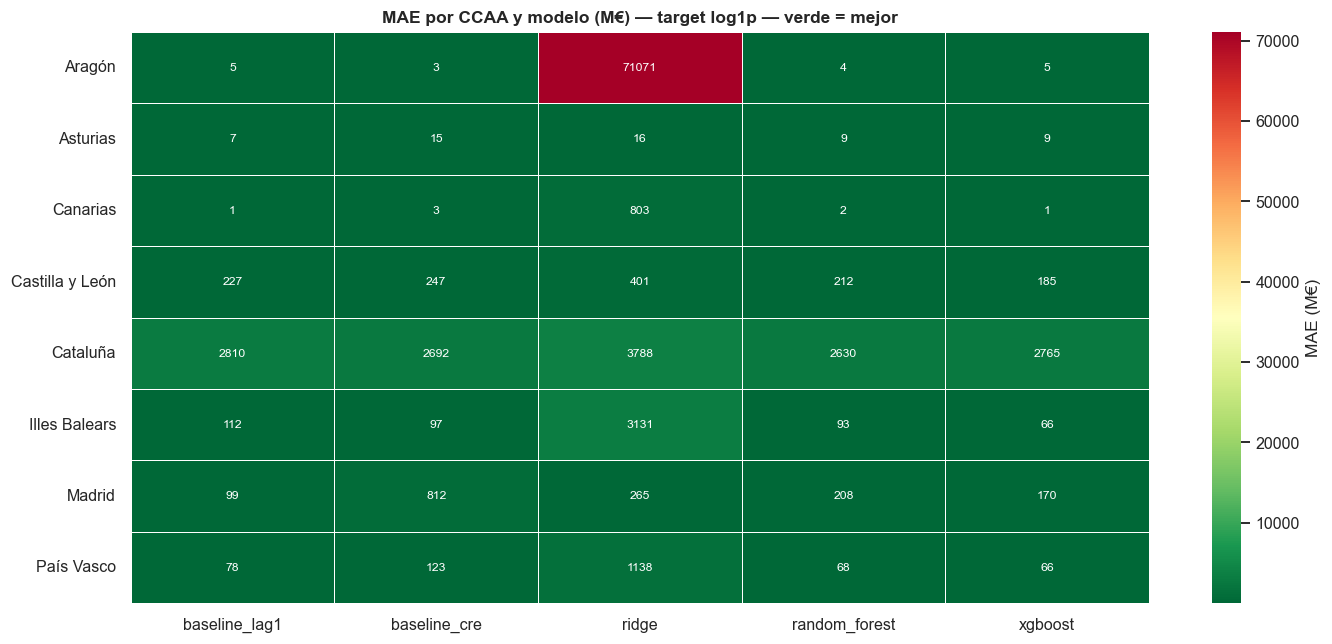

In [4]:
piv = res[res["mae"].notna()].pivot_table(index="ccaa", columns="modelo", values="MAE_M€")
order_m = ["baseline_lag1","baseline_cre","ridge","random_forest","xgboost"]
piv = piv[[c for c in order_m if c in piv.columns]]
fig, ax = plt.subplots(figsize=(13,6))
sns.heatmap(piv, annot=True, fmt=".0f", cmap="RdYlGn_r", norm=None,
            cbar_kws={"label":"MAE (M€)"}, linewidths=.4,
            annot_kws={"size":8})
ax.set_title("MAE por CCAA y modelo (M€) — target log1p — verde = mejor", weight="bold")
ax.set_xlabel(""); ax.set_ylabel("")
fig.tight_layout(); fig.savefig(REPORTS_DIR/"mae_heatmap.png", bbox_inches="tight", dpi=110); plt.show()

### 4.2 · Mejor baseline vs mejor ML por CCAA (¿aporta el ML?)

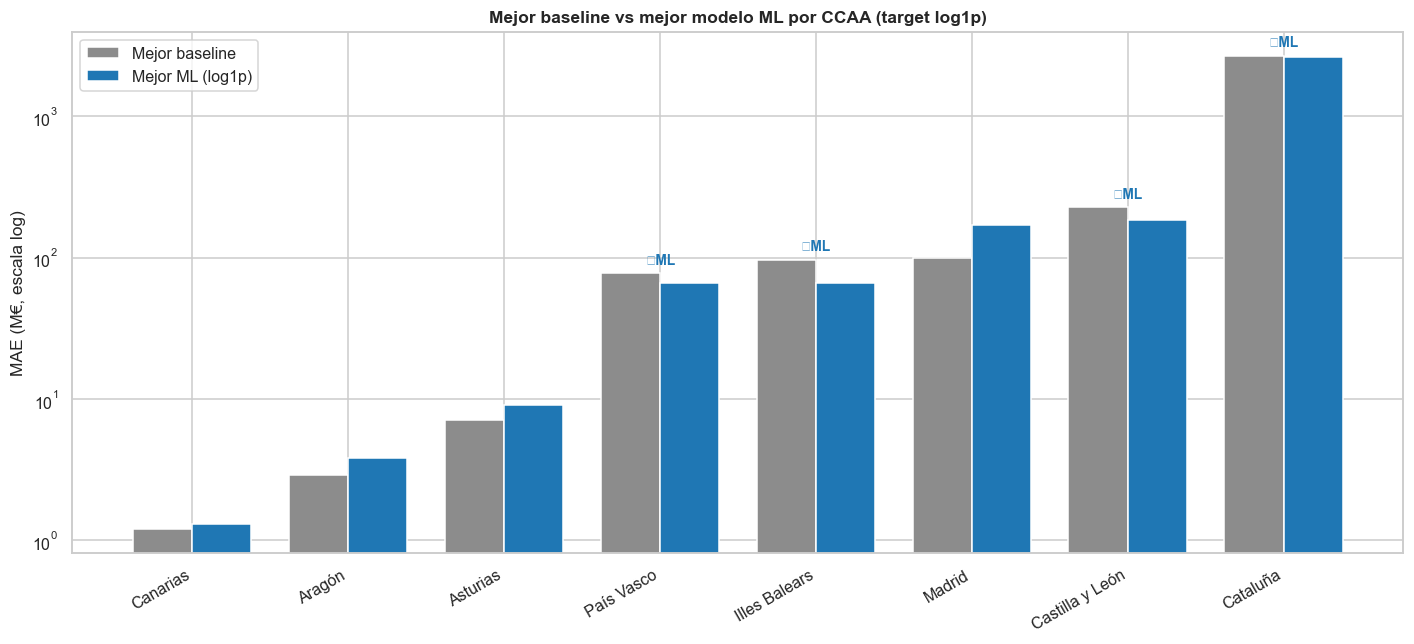

In [5]:
comp = []
for cc in res["ccaa"].unique():
    sub = res[(res["ccaa"]==cc) & res["mae"].notna()]
    if sub.empty: continue
    bl = sub[sub["modelo"].str.startswith("baseline")]["MAE_M€"].min()
    ml = sub[~sub["modelo"].str.startswith("baseline")]["MAE_M€"].min()
    comp.append((cc, bl, ml))
c = pd.DataFrame(comp, columns=["ccaa","MejorBaseline","MejorML"]).sort_values("MejorBaseline")
x = np.arange(len(c)); w=0.38
fig, ax = plt.subplots(figsize=(13,6))
b1=ax.bar(x-w/2, c["MejorBaseline"], w, label="Mejor baseline", color="#8c8c8c")
b2=ax.bar(x+w/2, c["MejorML"], w, label="Mejor ML (log1p)", color="#1f77b4")
ax.set_yscale("log"); ax.set_ylabel("MAE (M€, escala log)")
ax.set_xticks(x); ax.set_xticklabels(c["ccaa"], rotation=30, ha="right")
ax.set_title("Mejor baseline vs mejor modelo ML por CCAA (target log1p)", weight="bold")
for cc_i,(_,r_) in enumerate(c.iterrows()):
    gana = "ML" if r_["MejorML"]<r_["MejorBaseline"] else "baseline"
    ax.text(cc_i, max(r_["MejorML"],r_["MejorBaseline"])*1.15, "✓ML" if gana=="ML" else "", ha="center", color="#1f77b4", fontsize=9, weight="bold")
ax.legend(); fig.tight_layout(); fig.savefig(REPORTS_DIR/"baseline_vs_ml.png", bbox_inches="tight", dpi=110); plt.show()

### 4.3 · Predicho vs. real (mejor modelo de cada CCAA)

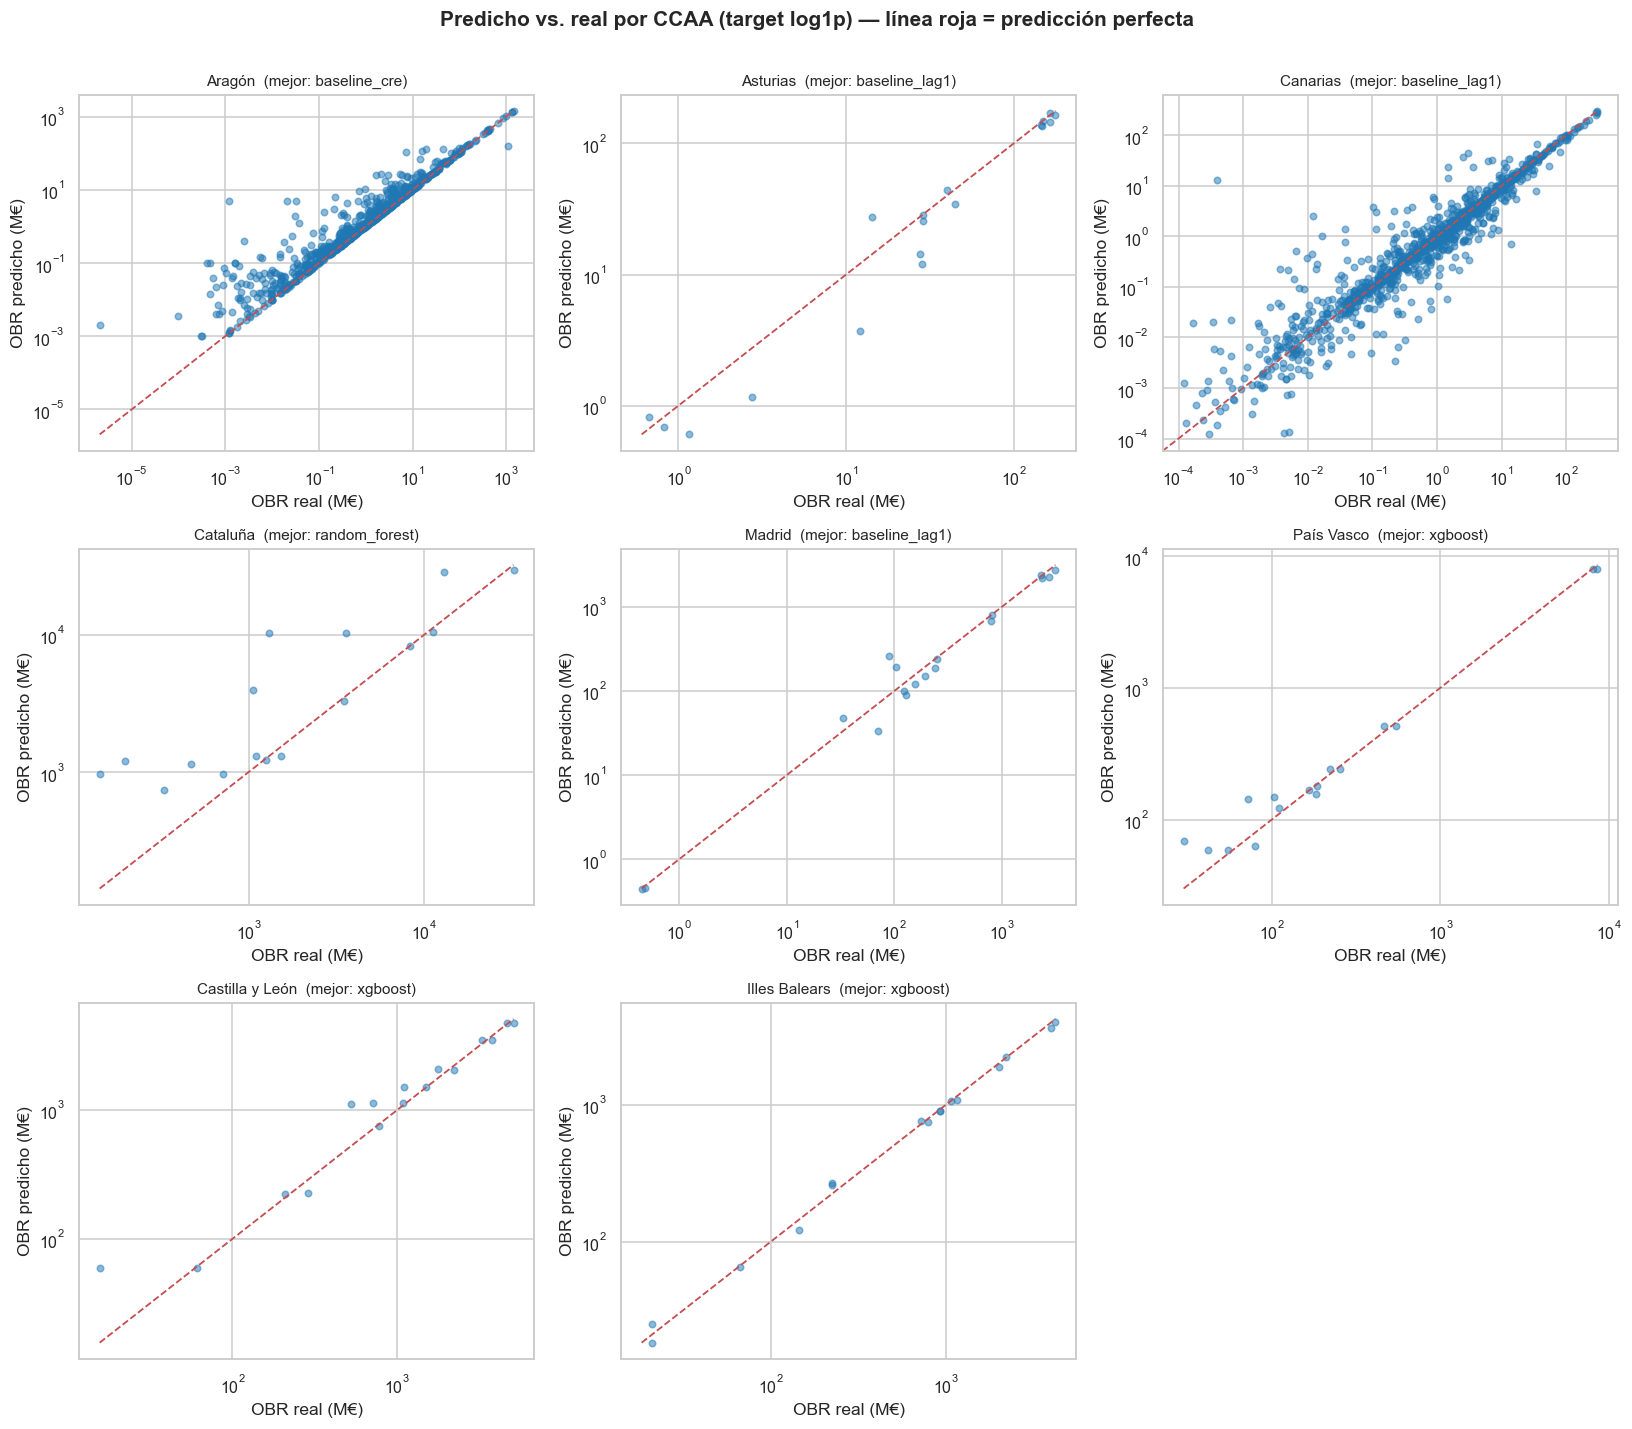

In [6]:
ccaas = [c for c in PRED]
n=len(ccaas); ncols=3; nrows=int(np.ceil(n/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.3*nrows)); axes=np.atleast_1d(axes).ravel()
for ax, cc in zip(axes, ccaas):
    info=PRED[cc]; y=info["y"]; p=info["preds"][info["best"]]
    ax.scatter(y/1e6, p/1e6, s=18, alpha=0.5, color="#1f77b4")
    lim=[min(y.min(),p.min())/1e6, max(y.max(),p.max())/1e6]
    ax.plot(lim, lim, "--", color="#c44e52", lw=1.2)
    ax.set_title(f"{cc}  (mejor: {info['best']})", fontsize=10)
    ax.set_xlabel("OBR real (M€)"); ax.set_ylabel("OBR predicho (M€)")
    try: ax.set_xscale("log"); ax.set_yscale("log")
    except Exception: pass
for ax in axes[n:]: ax.set_visible(False)
fig.suptitle("Predicho vs. real por CCAA (target log1p) — línea roja = predicción perfecta", y=1.005, weight="bold")
fig.tight_layout(); fig.savefig(REPORTS_DIR/"pred_vs_real.png", bbox_inches="tight", dpi=110); plt.show()

### 4.4 · Importancia de variables (CCAA donde gana un modelo de árboles)

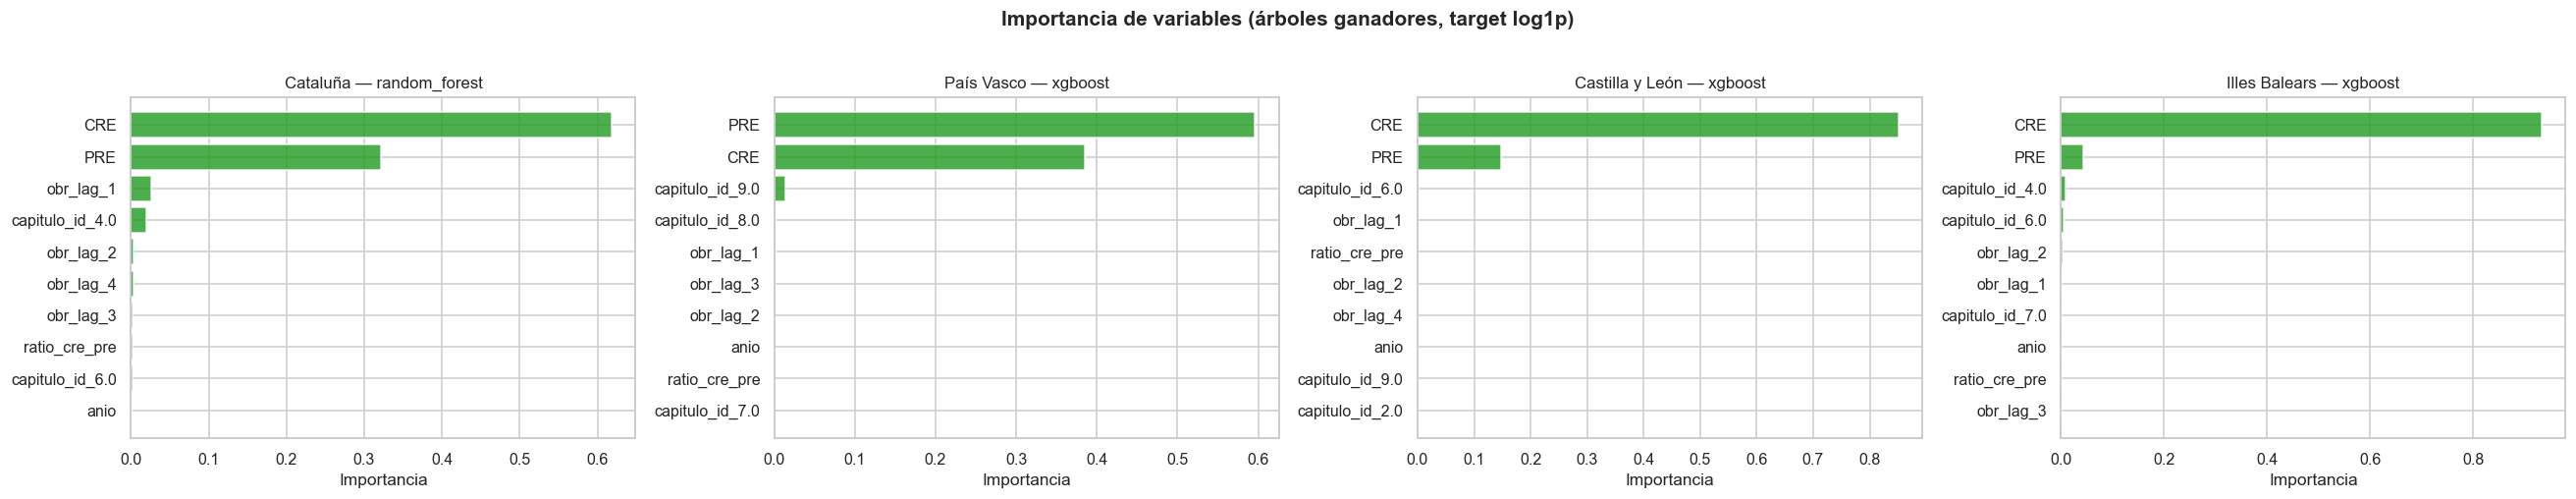

In [7]:
tree_winners = {cc:res[(res.ccaa==cc)&(res.ganador=='★')]['modelo'].iloc[0]
                for cc in res.ccaa.unique()
                if len(res[(res.ccaa==cc)&(res.ganador=='★')]) and
                   res[(res.ccaa==cc)&(res.ganador=='★')]['modelo'].iloc[0] in ('random_forest','xgboost')}
if tree_winners:
    fig, axes = plt.subplots(1, len(tree_winners), figsize=(6*len(tree_winners),4.5), squeeze=False); axes=axes.ravel()
    for ax,(cc,mdl) in zip(axes, tree_winners.items()):
        fn, imp = IMPORT[cc][mdl]
        s = pd.Series(imp, index=[f.replace('num__','').replace('cat__','') for f in fn]).sort_values().tail(10)
        ax.barh(s.index, s.values, color="#2ca02c", alpha=0.85)
        ax.set_title(f"{cc} — {mdl}", fontsize=11); ax.set_xlabel("Importancia")
    fig.suptitle("Importancia de variables (árboles ganadores, target log1p)", y=1.02, weight="bold")
    fig.tight_layout(); fig.savefig(REPORTS_DIR/"importancias.png", bbox_inches="tight", dpi=110); plt.show()
else:
    print("Ninguna CCAA tiene un árbol como ganador global.")

### 4.5 · Resumen: ganador por CCAA

In [8]:
win = res[res.ganador=="★"][["ccaa","grano","n_train","n_test","modelo","MAE_M€","bate_baseline"]]
n_ml = (win["bate_baseline"]=="sí").sum()
print(f"El ML supera al baseline en {n_ml}/{len(win)} CCAA evaluables.\n")
win.reset_index(drop=True)

El ML supera al baseline en 4/8 CCAA evaluables.



,ccaa,grano,n_train,n_test,modelo,MAE_M€,bate_baseline
0,Aragón,capítulo,3729,936,baseline_cre,2.9,no
1,Asturias,capítulo,45,18,baseline_lag1,7.1,no
2,Canarias,capítulo,5290,1220,baseline_lag1,1.2,no
3,Cataluña,capítulo,88,16,random_forest,2629.8,sí
4,Madrid,capítulo,41,18,baseline_lag1,99.1,no
5,País Vasco,capítulo,64,16,xgboost,65.8,sí
6,Castilla y León,capítulo,48,16,xgboost,184.7,sí
7,Illes Balears,capítulo,168,16,xgboost,66.4,sí


## 5 · Conclusiones

Idénticas a las del notebook `03_modelado_predictivo.ipynb` — la única diferencia es el **origen
de los datos** (tabla `feature_store_modelado` en **Azure PostgreSQL** en lugar del feature store
en parquet local). Los resultados del modelado deben coincidir, porque
`scripts/build_feature_store_azure.py` replica exactamente la ingeniería de features de
`src/features/builder.py`.

- **Predicción independiente por CCAA, en grano nativo.**
- **Los baselines son muy fuertes** (`CRE` y `obr_lag_1`): a grano fino **OBR ≈ CRE**.
- **El ML aporta valor solo en algunas CCAA**; el `log1p` no mejoró el resultado global.
- **Ventaja del origen Azure:** el feature store queda consultable por SQL y reutilizable por el
  dashboard sin depender de los ficheros parquet locales.

Figuras guardadas en `reports/modelado_azure/`.